In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

# Main repository directory
BASE_DIR = Path.cwd().parent

OUTPUT_DIR = BASE_DIR / "outputs"

print("Repository:", BASE_DIR)
print("Outputs folder:", OUTPUT_DIR)

Repository: C:\Users\Lenovo\OneDrive\Documents\StadioCare-performance-analysis
Outputs folder: C:\Users\Lenovo\OneDrive\Documents\StadioCare-performance-analysis\outputs


### Loading the saved predictions

In [3]:
# Load Model 1 predictions
model1_df = pd.read_csv(
    OUTPUT_DIR / "logistic_regression_predictions.csv"
)

# Load Model 2 predictions
model2_df = pd.read_csv(
    OUTPUT_DIR / "random_forest_predictions.csv"
)


if len(model1_df) != len(model2_df):
    raise ValueError("The models have different test-set sizes.")

if not np.array_equal(
    model1_df["Actual"].to_numpy(),
    model2_df["Actual"].to_numpy()
):
    raise ValueError(
        "The actual test labels differ between models. "
        "Use the same test set for both models."
    )

y_test = model1_df["Actual"].to_numpy()

y_pred_lr = model1_df["Predicted"].to_numpy()
y_prob_lr = model1_df["Readmission_Probability"].to_numpy()

y_pred_rf = model2_df["Predicted"].to_numpy()
y_prob_rf = model2_df["Readmission_Probability"].to_numpy()

print("Number of test observations:", len(y_test))
print("Actual readmissions:", np.sum(y_test == 1))
print("Actual non-readmissions:", np.sum(y_test == 0))

Number of test observations: 20153
Actual readmissions: 2151
Actual non-readmissions: 18002


### Recalculating the metrics consistently

In [4]:
def calculate_metrics(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_true, y_pred, zero_division=0
        ),
        "F1-score": f1_score(
            y_true, y_pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob)
    }


metrics_lr = calculate_metrics(
    y_test, y_pred_lr, y_prob_lr
)

metrics_rf = calculate_metrics(
    y_test, y_pred_rf, y_prob_rf
)

comparison_df = pd.DataFrame({
    "Metric": list(metrics_lr.keys()),
    "Logistic Regression": list(metrics_lr.values()),
    "Random Forest": list(metrics_rf.values())
})

comparison_df["Difference (RF - LR)"] = (
    comparison_df["Random Forest"]
    - comparison_df["Logistic Regression"]
)

display(
    comparison_df.style.format({
        "Logistic Regression": "{:.4f}",
        "Random Forest": "{:.4f}",
        "Difference (RF - LR)": "{:+.4f}"
    })
)

comparison_df.to_csv(
    OUTPUT_DIR / "model_comparison_metrics.csv",
    index=False
)

,Metric,Logistic Regression,Random Forest,Difference (RF - LR)
0,Accuracy,0.6567,0.6444,-0.0123
1,Precision,0.1661,0.1668,+0.0007
2,Recall,0.5514,0.5834,+0.0321
3,F1-score,0.2553,0.2594,+0.0041
4,ROC-AUC,0.6535,0.6711,+0.0176
5,PR-AUC,0.2011,0.2046,+0.0035


### Confusion matrices for both models

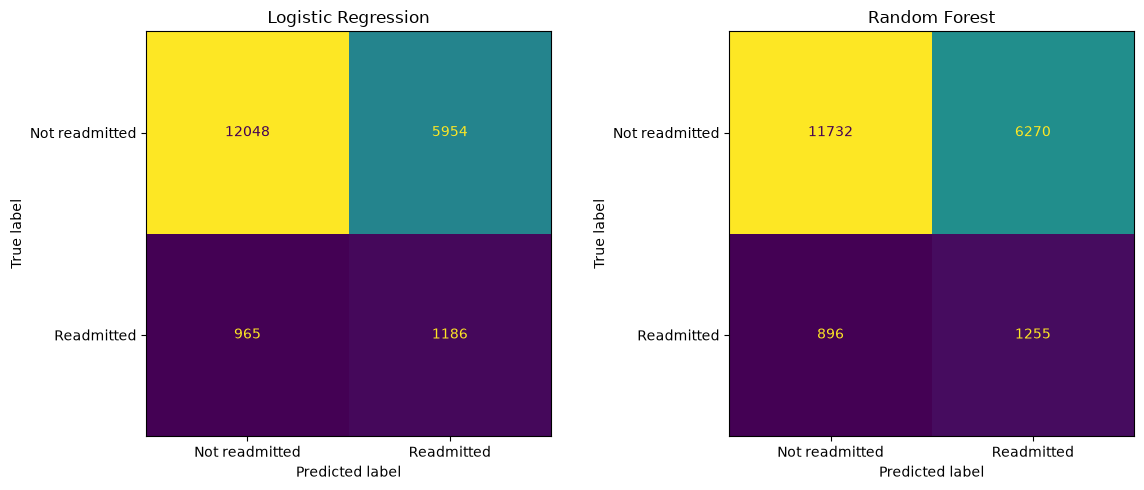

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_lr),
    display_labels=["Not readmitted", "Readmitted"]
).plot(
    ax=axes[0],
    values_format="d",
    colorbar=False
)

axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_rf),
    display_labels=["Not readmitted", "Readmitted"]
).plot(
    ax=axes[1],
    values_format="d",
    colorbar=False
)

axes[1].set_title("Random Forest")

plt.tight_layout()
plt.show()

### Comparing ROC curves

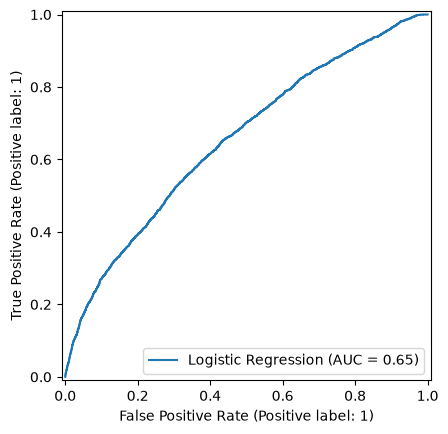

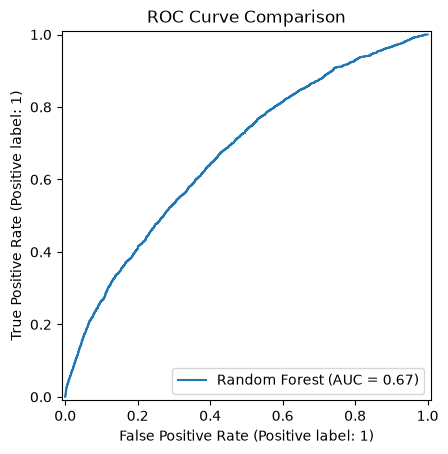

In [6]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest"
)

plt.title("ROC Curve Comparison")
plt.show()

### Compare Precision-Recall curves

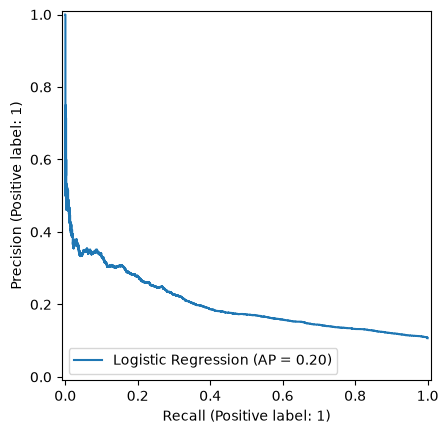

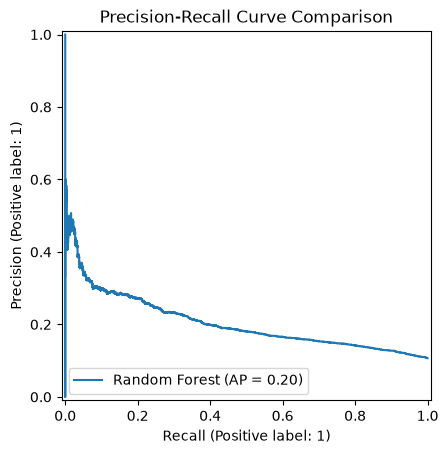

In [7]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_lr,
    name="Logistic Regression"
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest"
)

plt.title("Precision-Recall Curve Comparison")
plt.show()

### Bootstrap confidence intervals

##### For additional statistical context, we will estimate 95% bootstrap confidence intervals for the ROC-AUC and PR-AUC of each model.

In [8]:
def bootstrap_metric_ci(
    y_true,
    y_prob,
    metric_function,
    n_bootstrap=1000,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    scores = []

    for _ in range(n_bootstrap):
        indices = rng.choice(
            len(y_true),
            size=len(y_true),
            replace=True
        )

        y_sample = y_true[indices]
        prob_sample = y_prob[indices]

        # Skip samples containing only one class
        if len(np.unique(y_sample)) < 2:
            continue

        score = metric_function(
            y_sample,
            prob_sample
        )

        scores.append(score)

    lower = np.percentile(scores, 2.5)
    upper = np.percentile(scores, 97.5)

    return lower, upper, len(scores)

In [9]:
bootstrap_results = []

models = {
    "Logistic Regression": y_prob_lr,
    "Random Forest": y_prob_rf
}

metrics_to_bootstrap = {
    "ROC-AUC": roc_auc_score,
    "PR-AUC": average_precision_score
}

for model_name, probabilities in models.items():

    for metric_name, metric_function in metrics_to_bootstrap.items():

        lower, upper, valid_samples = bootstrap_metric_ci(
            y_test,
            probabilities,
            metric_function,
            n_bootstrap=1000,
            random_state=42
        )

        point_estimate = metric_function(
            y_test,
            probabilities
        )

        bootstrap_results.append({
            "Model": model_name,
            "Metric": metric_name,
            "Estimate": point_estimate,
            "95% CI Lower": lower,
            "95% CI Upper": upper,
            "Valid Bootstrap Samples": valid_samples
        })

bootstrap_df = pd.DataFrame(bootstrap_results)

display(
    bootstrap_df.style.format({
        "Estimate": "{:.4f}",
        "95% CI Lower": "{:.4f}",
        "95% CI Upper": "{:.4f}"
    })
)

bootstrap_df.to_csv(
    OUTPUT_DIR / "bootstrap_confidence_intervals.csv",
    index=False
)

,Model,Metric,Estimate,95% CI Lower,95% CI Upper,Valid Bootstrap Samples
0,Logistic Regression,ROC-AUC,0.6535,0.6415,0.6668,1000
1,Logistic Regression,PR-AUC,0.2011,0.1875,0.2156,1000
2,Random Forest,ROC-AUC,0.6711,0.6595,0.6829,1000
3,Random Forest,PR-AUC,0.2046,0.1904,0.2193,1000


In [10]:
def paired_bootstrap_auc_difference(
    y_true,
    prob_lr,
    prob_rf,
    n_bootstrap=1000,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    y_true = np.asarray(y_true)
    prob_lr = np.asarray(prob_lr)
    prob_rf = np.asarray(prob_rf)

    differences = []

    for _ in range(n_bootstrap):

        indices = rng.choice(
            len(y_true),
            size=len(y_true),
            replace=True
        )

        y_sample = y_true[indices]

        if len(np.unique(y_sample)) < 2:
            continue

        auc_lr = roc_auc_score(
            y_sample,
            prob_lr[indices]
        )

        auc_rf = roc_auc_score(
            y_sample,
            prob_rf[indices]
        )

        differences.append(auc_rf - auc_lr)

    differences = np.asarray(differences)

    observed_difference = (
        roc_auc_score(y_true, prob_rf)
        - roc_auc_score(y_true, prob_lr)
    )

    lower = np.percentile(differences, 2.5)
    upper = np.percentile(differences, 97.5)

    return observed_difference, lower, upper, len(differences)


auc_difference, auc_lower, auc_upper, valid_samples = (
    paired_bootstrap_auc_difference(
        y_test,
        y_prob_lr,
        y_prob_rf,
        n_bootstrap=1000,
        random_state=42
    )
)

print(f"ROC-AUC difference (RF - LR): {auc_difference:.4f}")
print(f"95% CI lower bound: {auc_lower:.4f}")
print(f"95% CI upper bound: {auc_upper:.4f}")
print(f"Valid bootstrap samples: {valid_samples}")

ROC-AUC difference (RF - LR): 0.0176
95% CI lower bound: 0.0081
95% CI upper bound: 0.0261
Valid bootstrap samples: 1000


### Save the comparison results

In [11]:
comparison_summary = pd.DataFrame({
    "Measure": [
        "ROC-AUC difference (RF - LR)",
        "95% CI lower",
        "95% CI upper",
        "Valid bootstrap samples"
    ],
    "Value": [
        auc_difference,
        auc_lower,
        auc_upper,
        valid_samples
    ]
})

comparison_summary.to_csv(
    OUTPUT_DIR / "paired_auc_comparison.csv",
    index=False
)

print("Comparison files saved successfully.")

Comparison files saved successfully.
